<a href="https://colab.research.google.com/github/jullee96/translateDocs/blob/main/translate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 사전 준비 

### papago API 키 받기
-  https://developers.naver.com/apps/#/register


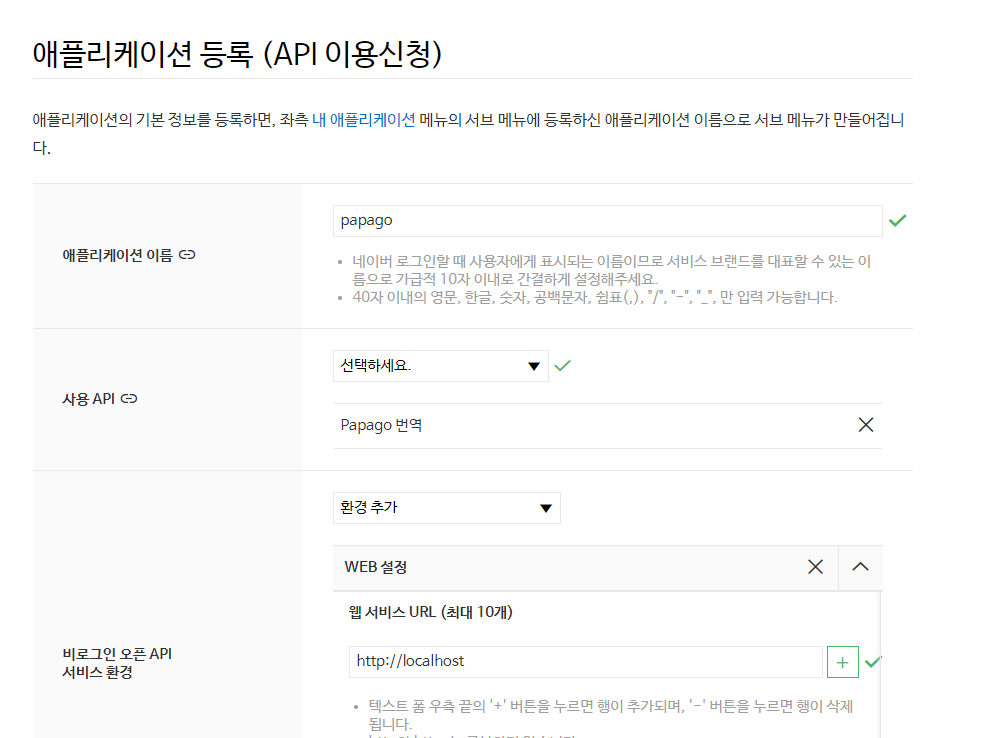

### 라이브러리 설치하기
- python-docx
- chromium-chromedriver
- selenium
- Scrapy

In [1]:
!pip install python-docx

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
!apt install chromium-chromedriver

Reading package lists... Done
Building dependency tree       
Reading state information... Done
chromium-chromedriver is already the newest version (104.0.5112.101-0ubuntu0.18.04.1).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [3]:
!pip install selenium

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [5]:
!pip install Scrapy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## 사용방법
### 1. 번역할 데이터 위치시키기
- ./data/번역할파일명.docx

### 2. getDocData('번역할파일명') 호출해주기
- 번역 결과물 : ./result/번역할파일명_ko.docx

In [6]:
import pandas as pd
import requests, json
import os

from selenium import webdriver
from selenium.webdriver.support.ui import Select
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from time import sleep
from scrapy.http import TextResponse
from tqdm import notebook
from docx import Document

In [7]:
def createFolder(directory):
  try:
    if not os.path.exists(directory):
      os.makedirs(directory)
  except OSError:
      print("error to make dir" + directory)

In [8]:
# 없으면 data 폴더와 result 폴더 생성
createFolder('./data')
createFolder('./result')

In [9]:
CLIENT_ID, CLIENT_SECRET = "Jv7iFVryPMs7fnrqCcWo", "CWwaxBwXWP"

In [10]:
def translate(txt):
    url = "https://openapi.naver.com/v1/papago/n2mt"
    params = {
        "source" : "en",
        "target" : "ko",
        "text" : txt
    }

    headers = {
        "Content-Type":"application/json",
        "X-Naver-Client-Id": CLIENT_ID,
        "X-Naver-Client-Secret" : CLIENT_SECRET
    }
    response = requests.post(url, json.dumps(params), headers=headers) 
    return response.json()["message"]["result"]["translatedText"]

In [19]:
def getDocData(source):
  # data 디렉토리로 파일 가져오기
  # source 변수에 번역할 파일 이름 입력
  sourceLanguageCode = 'en'
  global target_path
  target_path = './result/'+source+'_ko.docx'
  targetLanguageCode = 'ko'

  doc = Document('./data/'+source+'.docx')
  paragraphs = [para.text for para in doc.paragraphs]
  return paragraphs

In [20]:
result_doc = Document()
paragraphs =  getDocData('chap123')  

### 로컬에서 사용할 경우
```
# chromedriver.exe or .sh 파일이 있는 곳의 위치
driver = webdriver.Chrome("C:\\Users\\User\\chromedriver.exe")
```

### colab 에서 사용한다면  
- colab과 같은 클라우드 환경에서는 webdriver를 headless로 밖에 못씀 
- 로컬에서 사용할 경우 옵션 안줘도됨

In [21]:
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
driver = webdriver.Chrome('chromedriver', chrome_options=chrome_options)

path = "https://papago.naver.com/?sk=en&tk=ko"

response = requests.get(path)
driver.get(path)
driver.set_window_size(600,600)
print('전체 : ', len(paragraphs))
ing =  0
for i in notebook.tqdm(range(0,len(paragraphs))):
    
    text_area = driver.find_element(By.CSS_SELECTOR, '#txtSource')
    
    try:
        if len(paragraphs[i]) != 0 or paragraphs[i] != '' :
            if paragraphs[i].isspace() != True: 
                ing = i
                text_area.send_keys(paragraphs[i])
                sleep(3)
                target = driver.find_element("xpath", '//*[@id="txtTarget"]/span').text
                result_doc.add_paragraph(target)
                driver.find_element("xpath", '//*[@id="sourceEditArea"]/button').click()
        else: 
            result_doc.add_paragraph(paragraphs[i])
    except:
        print(i," >> ",paragraphs[i])

result_doc.save(target_path)    
driver.quit()

print("\n\nDocument translation is completed.")

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: DeprecationWarning: use options instead of chrome_options
  """


전체 :  8


  0%|          | 0/8 [00:00<?, ?it/s]



Document translation is completed.


In [17]:
# 테스트 > 문제가있는 행 문제파악용
# driver = webdriver.Chrome("C:\\Users\\User\\aivle\\chromedriver.exe")
# path = "https://papago.naver.com/?sk=en&tk=ko"

# response = requests.get(path)
# driver.get(path)
# driver.set_window_size(600,600)
            
# text_area = driver.find_element(By.CSS_SELECTOR, '#txtSource')
# if len(paragraphs[554]) != 0 or paragraphs[116] != '' :
#     if paragraphs[554].isspace() != True: 
#         ing = i
#         text_area.send_keys(paragraphs[554])
#         sleep(2)
#         target = driver.find_element("xpath", '//*[@id="txtTarget"]/span').text
#         doc.add_paragraph(target)
#         driver.find_element("xpath", '//*[@id="sourceEditArea"]/button').click()
# else: 
#     doc.add_paragraph(paragraphs[554])

# print("\n\nDocument translation is completed.")